<a href="https://colab.research.google.com/github/RobJavVar/DataSciencePsychNeuro/blob/master/ExerciseSubmissions/06_visualization-through-human-eyes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 6: More plotting options

In this homework, you'll practice more advanced plotting options from `ggplot`.

Just like the prior homework, we will be using the [gapminder](https://cran.r-project.org/web/packages/gapminder/index.html) dataset. It contains  information about population, life expectancy and per capita GDP by country over time.

---
# 1. Multipanel figures (7 points)

Last week, we visualized the change in life expectancy over time for every country in one plot. An alternative method is to use facet panels to split each country into its own plot.

To start, load the `gapminder` dataset from the last set of exercises, as well as the `tidyverse`.

In [3]:
#loading..
library(gapminder)
library(tidyverse)

Next, create a subset of data that only includes the 25 countries from the `Americas` continent. Now we can add a `facet_wrap` layer to our line plot to create the panels by country. Additionally, to make the x-axis values easier to read, add a `theme` layer to rotate the text by 45 degrees.

In [12]:
head(gapminder)
library(dplyr)


country,continent,year,lifeExp,pop,gdpPercap
<fct>,<fct>,<int>,<dbl>,<int>,<dbl>
Afghanistan,Asia,1952,28.801,8425333,779.4453
Afghanistan,Asia,1957,30.332,9240934,820.8530
Afghanistan,Asia,1962,31.997,10267083,853.1007
Afghanistan,Asia,1967,34.020,11537966,836.1971
Afghanistan,Asia,1972,36.088,13079460,739.9811
Afghanistan,Asia,1977,38.438,14880372,786.1134


In [18]:
print(gapminder)

# A tibble: 1,704 × 6
   country     continent  year lifeExp      pop gdpPercap
   <fct>       <fct>     <int>   <dbl>    <int>     <dbl>
 1 Afghanistan Asia       1952    28.8  8425333      779.
 2 Afghanistan Asia       1957    30.3  9240934      821.
 3 Afghanistan Asia       1962    32.0 10267083      853.
 4 Afghanistan Asia       1967    34.0 11537966      836.
 5 Afghanistan Asia       1972    36.1 13079460      740.
 6 Afghanistan Asia       1977    38.4 14880372      786.
 7 Afghanistan Asia       1982    39.9 12881816      978.
 8 Afghanistan Asia       1987    40.8 13867957      852.
 9 Afghanistan Asia       1992    41.7 16317921      649.
10 Afghanistan Asia       1997    41.8 22227415      635.
# ℹ 1,694 more rows


In [23]:
americas <- gapminder %>%
    filter (continent == 'Americas') 
print(americas)

# A tibble: 300 × 6
   country   continent  year lifeExp      pop gdpPercap
   <fct>     <fct>     <int>   <dbl>    <int>     <dbl>
 1 Argentina Americas   1952    62.5 17876956     5911.
 2 Argentina Americas   1957    64.4 19610538     6857.
 3 Argentina Americas   1962    65.1 21283783     7133.
 4 Argentina Americas   1967    65.6 22934225     8053.
 5 Argentina Americas   1972    67.1 24779799     9443.
 6 Argentina Americas   1977    68.5 26983828    10079.
 7 Argentina Americas   1982    69.9 29341374     8998.
 8 Argentina Americas   1987    70.8 31620918     9140.
 9 Argentina Americas   1992    71.9 33958947     9308.
10 Argentina Americas   1997    73.3 36203463    10967.
# ℹ 290 more rows


geom_smooth: na.rm = FALSE, orientation = NA, se = TRUE
stat_smooth: na.rm = FALSE, orientation = NA, se = TRUE
position_identity 

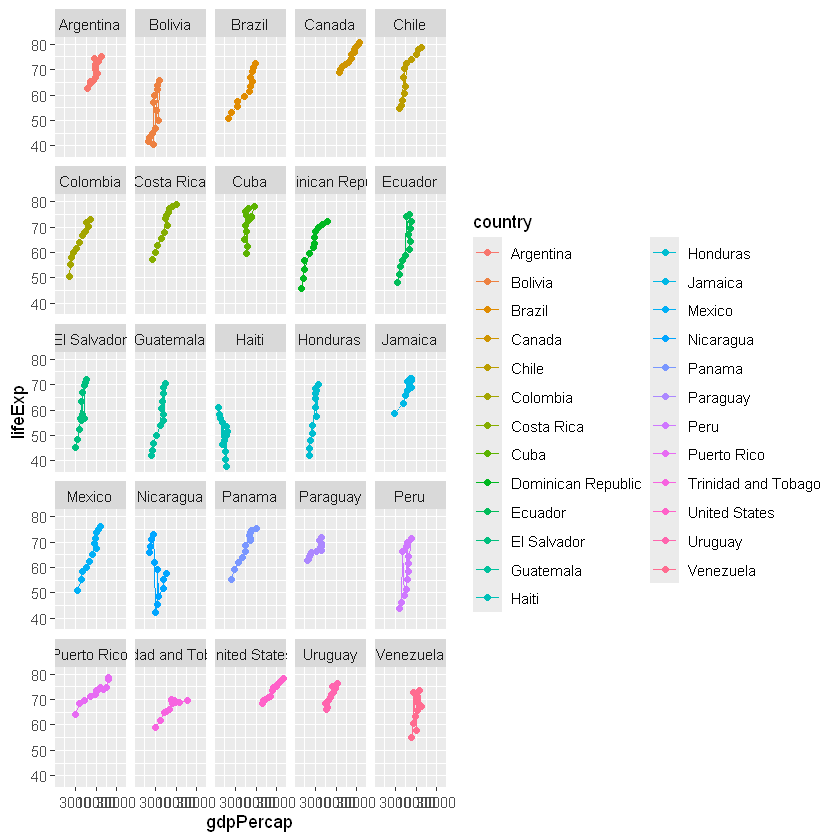

In [29]:
ggplot(americas, aes(x = gdpPercap, y = lifeExp, color = country)) +
  geom_point(alpha = 0.4) +
  scale_x_log10() + 
  geom_point() + geom_line() + facet_wrap(~country) # new add for exercise6
geom_smooth()

#based off of plot from last exercise but using americas dataset

Imagine that we wanted to publish this figure in a manuscript. Make the following changes to the code from the previous question to create a cleaner figure:

* Change the y-axis label (using `labs` layer)
* Add a figure title (using `labs` layer)
* Add a legend (using `labs` layer)
* Rotate x-axis value text to 90 degrees

*Hint: legend titles are set using the same names used in the aes specification. So, we need to add a `color` aes mapping to the global plot definition and reference this in the `labs` layer to specify the legend name.*

geom_smooth: na.rm = FALSE, orientation = NA, se = TRUE
stat_smooth: na.rm = FALSE, orientation = NA, se = TRUE
position_identity 

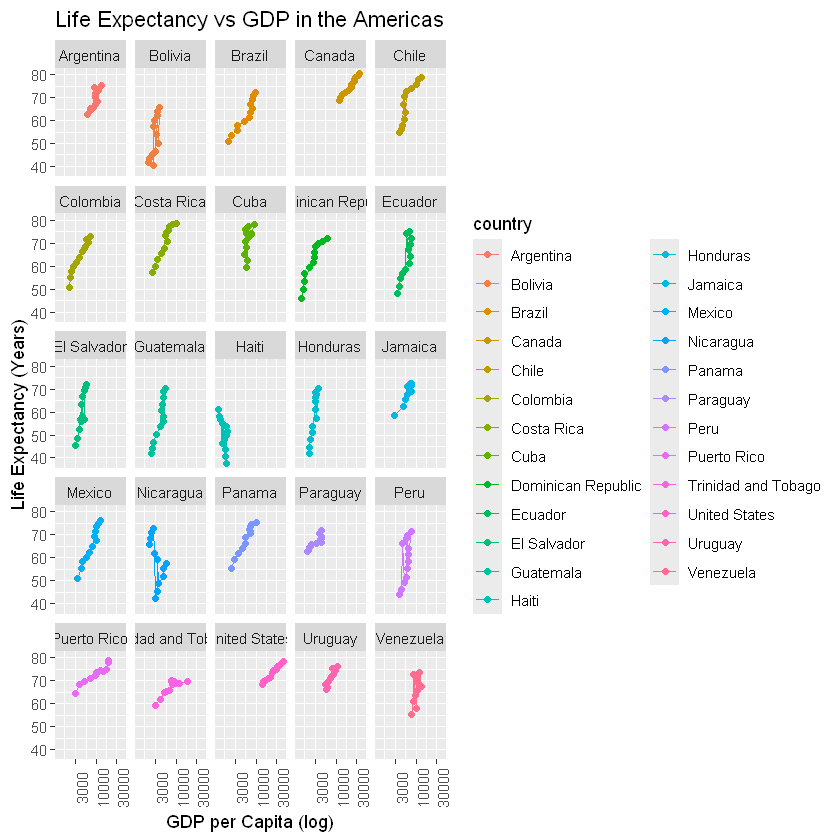

In [35]:
#Cleaning up fig
#based off of plot from last exercise but using americas dataset

ggplot(americas, aes(x = gdpPercap, y = lifeExp, color = country)) +
  geom_point(alpha = 0.4) +
  scale_x_log10() + 
  geom_point() + geom_line() + facet_wrap(~country)+ # new add for exercise6
    labs(
    title = "Life Expectancy vs GDP in the Americas",
    y = "Life Expectancy (Years)",
    x = "GDP per Capita (log)",
  ) +
  theme(
    axis.text.x = element_text(angle = 90)
  )
geom_smooth()


Now let's look at how life expectancy varies by continent over time. Create a multipanel figure where each panel contains five boxplots (one for each continent) and each panel represents one year of data. Include a legend instead of x-axis title and labels.

*Hint: the `theme` layer allows you to set attributes as `element_blank()`.*

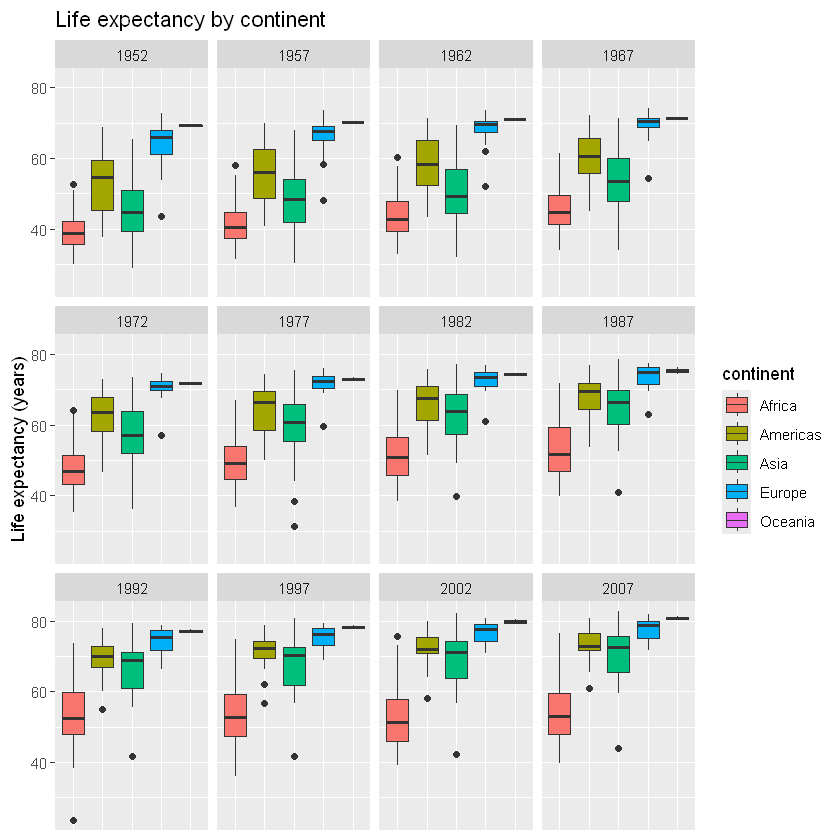

In [38]:
ggplot(gapminder, aes(x = continent, y = lifeExp, fill = continent)) +
  geom_boxplot() +
  facet_wrap(~ year) +
  labs(
    title = "Life expectancy by continent",
    x = NULL,
    y = "Life expectancy (years)",
  ) +
  theme(
    axis.title.x = element_blank(), #to remove axes and rely only on the legend
    axis.text.x  = element_blank(),
    axis.ticks.x = element_blank()
  )



---
# 2. Increasing data density (3 pts)

The above plots have nice readability, but they probably use more ink than is necessary. Take your boxplots from the last question and edit them to improve the data-to-ink ratio.

Hint: Double check your axis labels!

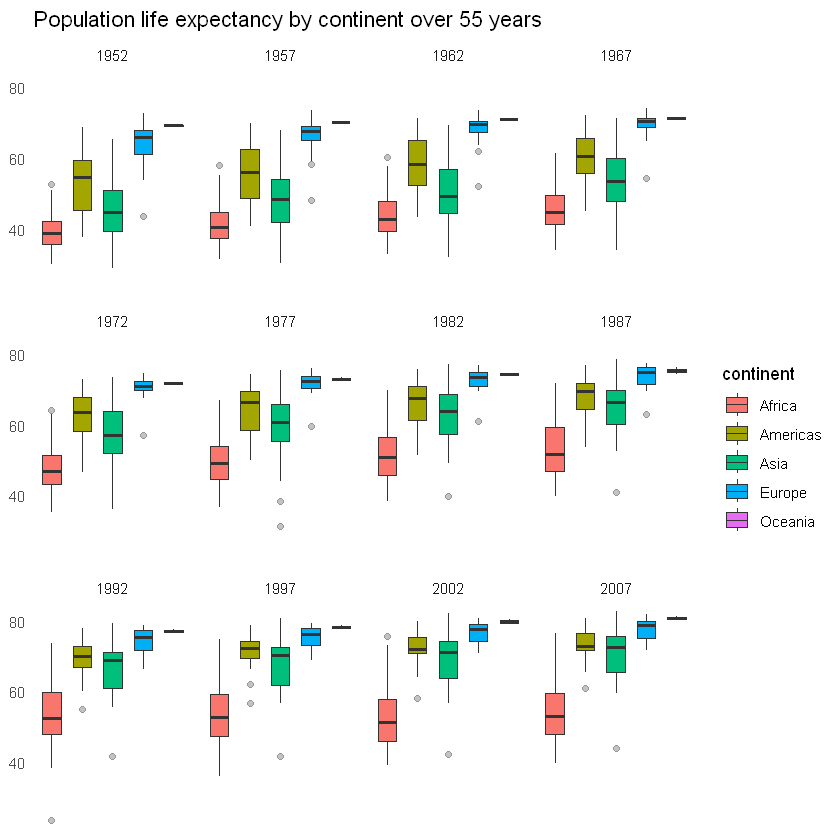

In [51]:
ggplot(gapminder, aes(x = continent, y = lifeExp, fill = continent)) +
  geom_boxplot(outlier.alpha = 0.3, width = 0.6) +
  facet_wrap(~ year) +
  labs(
    title = "Population life expectancy by continent over 55 years",
    x = NULL,

    y = "Life Expectancy (years)"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.title.y = element_blank(), #i think this is useless 
    panel.grid.minor = element_blank(),# remove extra gridlines
    panel.grid.major = element_blank(),
    strip.background = element_blank() 
  )


**DUE:** 5pm EST, Feb 12, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*

**GenAI Utilization** Did you utilize any generative AI tools on this assignment? If so, please list the item and the paste respective prompt you used.

I used it for the last two sections for help on cleaning up the plots as i couldnt remove an overlapping text 

- "i need to remove the bottom text that is overlapping"
- suggested adding:
- axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
